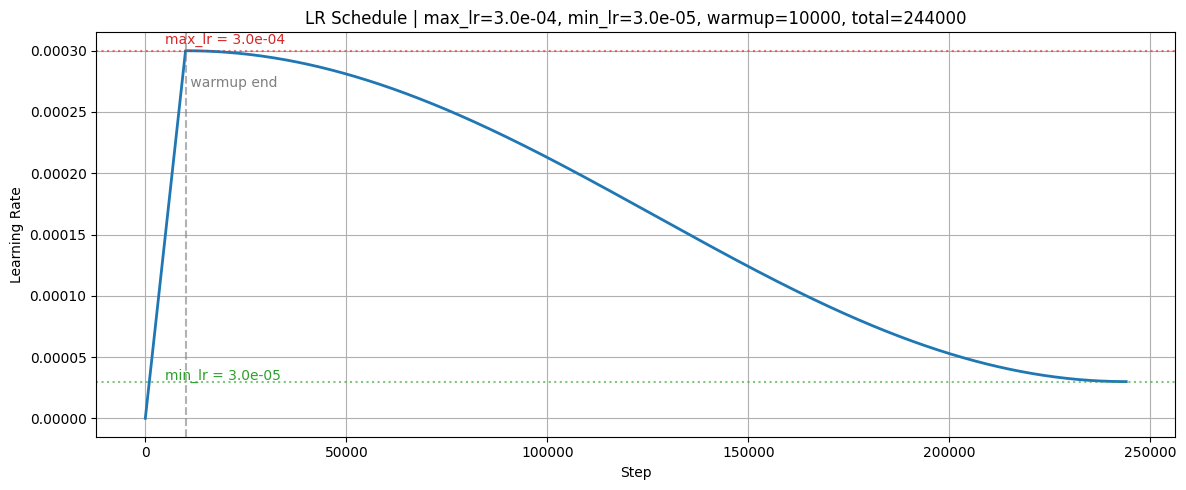

In [1]:
# 测试warmup + cosine Learnning Rate

import math
import matplotlib.pyplot as plt

def get_lr(step, max_lr, min_lr, warmup_steps, total_steps):
    assert total_steps > warmup_steps, \
        f"total_steps ({total_steps}) must be > warmup_steps ({warmup_steps})"

    if step < warmup_steps:
        return max_lr * (step + 1) / warmup_steps
    if step >= total_steps:
        return min_lr

    progress = (step - warmup_steps) / (total_steps - warmup_steps)
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return min_lr + (max_lr - min_lr) * cosine


# ===== 参数 =====
max_lr = 3e-4
min_lr = 3e-5
warmup_steps = 10000
total_steps = 244_000

# 采样（不用每一步都算，画图采样即可）
sample_steps = list(range(0, total_steps + 1, max(total_steps // 2000, 1)))
lrs = [get_lr(s, max_lr, min_lr, warmup_steps, total_steps) for s in sample_steps]

# ===== 画图 =====
plt.figure(figsize=(12, 5))
plt.plot(sample_steps, lrs, linewidth=2, color="tab:blue")

# 标注关键点
plt.axvline(warmup_steps, color="gray", linestyle="--", alpha=0.6)
plt.text(warmup_steps, max_lr * 0.9, " warmup end", color="gray")

plt.axhline(max_lr, color="tab:red", linestyle=":", alpha=0.6)
plt.text(total_steps * 0.02, max_lr * 1.02, f"max_lr = {max_lr:.1e}", color="tab:red")

plt.axhline(min_lr, color="tab:green", linestyle=":", alpha=0.6)
plt.text(total_steps * 0.02, min_lr * 1.05, f"min_lr = {min_lr:.1e}", color="tab:green")

plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title(
    f"LR Schedule | max_lr={max_lr:.1e}, min_lr={min_lr:.1e}, "
    f"warmup={warmup_steps}, total={total_steps}"
)
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# 你的调度函数

min_lr = 3e-5
max_lr = 3e-4
warmup_steps = 1200
max_steps = 500_000

lr = get_lr(5000, max_lr, min_lr, warmup_steps, max_steps)

print(lr)

0.0002999613368627738
